# Analysis of noise grouping using tSNE (2014)

###### Pretrained CNN + KPCA

In [1]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

## 1. Preprocess title embeddings for tSNE
###### r=0.9

In [2]:
df_emb = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.noise', sep='\t')
df_emb.head(5)

,ent_id:token,ent_emb:float_seq
0,0,-0.3905891282573314 -0.5488710329996425 -0.768...
1,1,2.017747327991471 -1.1367260536578117 0.576483...
2,3,-1.8498262567949695 0.2984349407360305 -0.2580...
3,2,0.8671690671566937 -0.14107643199594114 -0.443...
4,4,0.09842190118294013 -0.2574671122606531 -0.872...


In [3]:
df_emb.rename(columns={"ent_emb:float_seq": "emb", "ent_id:token": "id"}, inplace=True)
df_emb["emb"] = df_emb["emb"].apply(lambda x: np.fromstring(x, dtype=np.float32, sep=' '))
df_emb.head(5)

,id,emb
0,0,"[-0.39058912, -0.54887104, -0.76889396, -0.559..."
1,1,"[2.0177474, -1.136726, 0.57648325, 0.6331659, ..."
2,3,"[-1.8498262, 0.29843494, -0.2580807, 0.6745085..."
3,2,"[0.8671691, -0.14107643, -0.44316986, 0.787506..."
4,4,"[0.0984219, -0.25746712, -0.87232226, -1.68549..."


In [4]:
df_cat = pd.read_csv('../../../Amazon_Sports_and_Outdoors/Amazon_Sports_and_Outdoors.item', sep='\t')
df_cat.head(5)

,item_id:token,title:token,price:float,brand:token,categories:token_seq,sales_type:token,sales_rank:float
0,0,Ghost Inc Glock Armorers Tool 3/32 Punch,9.99,Ghost,"'Sports & Outdoors', 'Hunting', 'Hunting & Fis...",Sports &amp; Outdoors,532941.0
1,1,5 LED Bicycle Rear Tail Red Bike Torch Laser B...,8.26,NaN,"'Lights & Reflectors', 'Sports & Outdoors', 'C...",Toys & Games,15617.0
2,3,Black Mountain Products Resistance Band Set wi...,32.99,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0
3,2,Black Mountain Products Single Resistance Band...,10.49,Black Mountain,"'Accessories', 'Exercise Bands', 'Sports & Out...",Sports &amp; Outdoors,1010.0
4,4,Outers Universal 32-Piece Blow Molded Gun Clea...,21.99,Outers,"'Sports & Outdoors', 'Hunting', 'Gun Cleaning ...",Sports &amp; Outdoors,26457.0


In [5]:
df_cat = df_cat.rename(columns={"categories:token_seq": "cat", "item_id:token": "id"})
df_cat['cat'] = df_cat['cat'].apply(lambda x: [entry for entry in str(x).split(',')])
df_cat.drop(columns=['price:float', 'title:token', 'sales_rank:float', 'sales_type:token'], inplace=True)
df_cat.head(5)

,id,brand:token,cat
0,0,Ghost,"['Sports & Outdoors', 'Hunting', 'Hunting & ..."
1,1,NaN,"['Lights & Reflectors', 'Sports & Outdoors', ..."
2,3,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ..."
3,2,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ..."
4,4,Outers,"['Sports & Outdoors', 'Hunting', 'Gun Cleani..."


## 2. Create colour column

In [6]:
categories_2d = df_cat['cat'].tolist()

categories = []
for entry in categories_2d:
    for cat in entry:
        categories.append(cat)

categories = set(categories)

In [7]:
colour_dict = {cat: np.random.randint(0, 256, size=3) for cat in categories}

def rgb_mean(cat_list):
    arr = np.array([colour_dict[x] for x in cat_list])
    return arr.mean(axis=0)

In [8]:
df_cat['colour'] = df_cat['cat'].apply(rgb_mean)
df_cat.head(5)

,id,brand:token,cat,colour
0,0,Ghost,"['Sports & Outdoors', 'Hunting', 'Hunting & ...","[188.6, 89.2, 114.6]"
1,1,NaN,"['Lights & Reflectors', 'Sports & Outdoors', ...","[26.5, 94.25, 157.25]"
2,3,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ...","[80.5, 99.75, 96.25]"
3,2,Black Mountain,"['Accessories', 'Exercise Bands', 'Sports & ...","[80.5, 99.75, 96.25]"
4,4,Outers,"['Sports & Outdoors', 'Hunting', 'Gun Cleani...","[181.8, 121.2, 146.8]"


## 3. Sample items and analise with tSNE

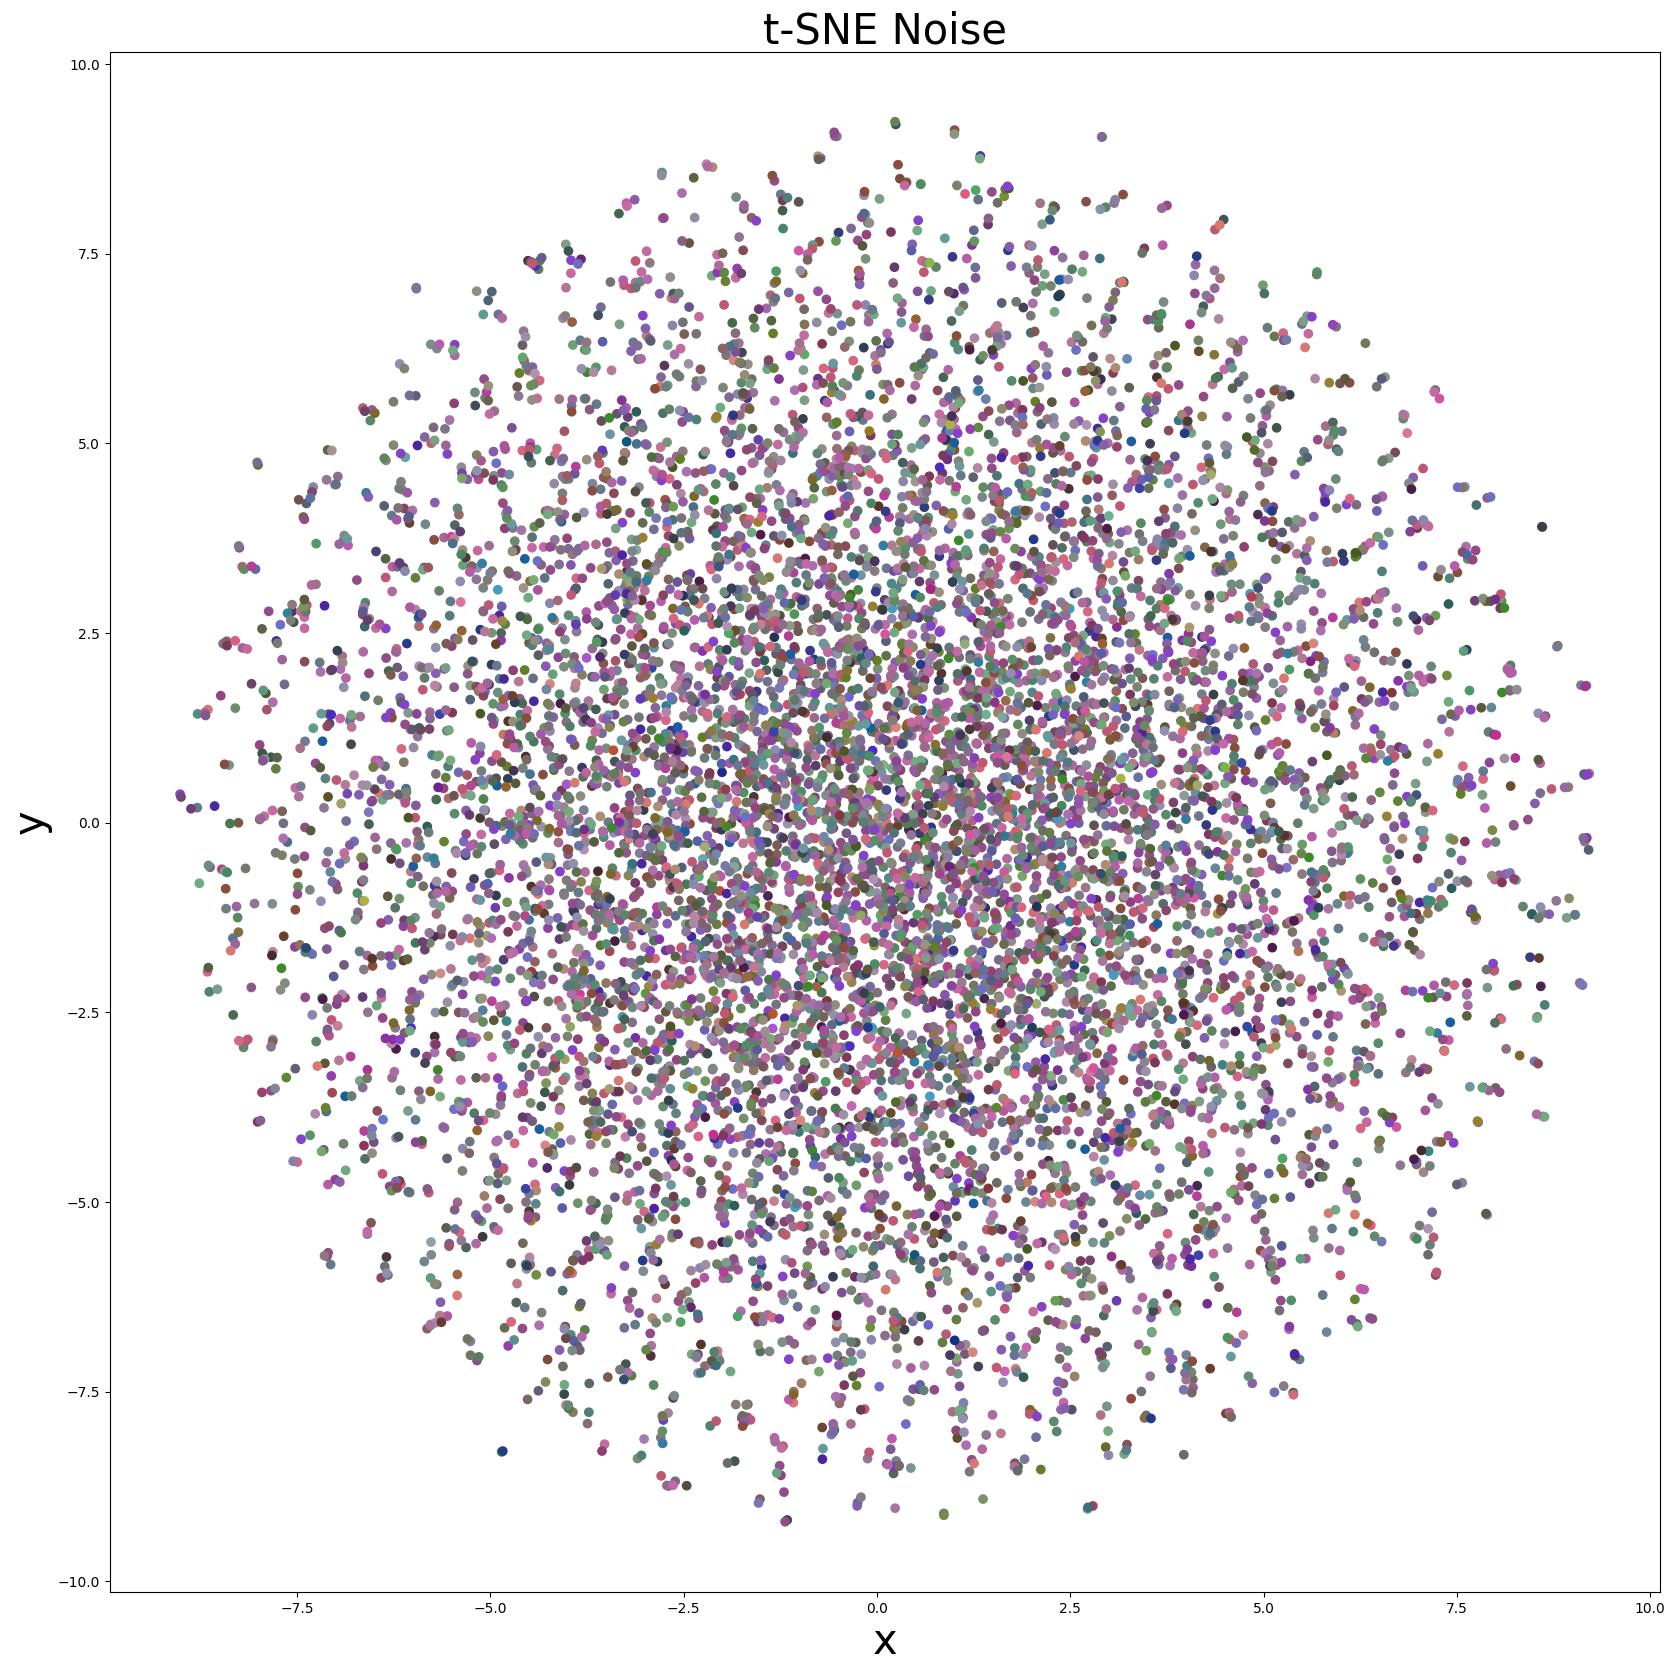

In [9]:
SAMPLE_SIZE = 10000

emb_series = df_emb[df_emb['emb'].notnull()]['emb']

X = np.vstack(emb_series.values)

rand_ind = np.random.choice(range(len(X)), SAMPLE_SIZE, replace=False)
X = X[rand_ind]

X_emb = TSNE(n_components=2, perplexity=32).fit_transform(X)
plt.figure(figsize=(20, 20))
plt.title(f't-SNE Noise', fontsize=30)
plt.xlabel('x', fontsize=30)
plt.ylabel('y', fontsize=30)
plt.scatter(X_emb[:,0], X_emb[:,1], c=df_cat['colour'][rand_ind] / 255.0)
plt.show()